In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Task 1 - Automated inspection of a document under uneven lightening

In [21]:
image = cv2.imread("sudoku.png", cv2.IMREAD_GRAYSCALE)
image.shape

(563, 558)

In [16]:
#image = image.astype(np.uint8)
thresholds = [50, 80, 127, 180]
global_masks = [cv2.threshold(image, t, 255, cv2.THRESH_BINARY)[1] for t in thresholds]
adaptive = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)

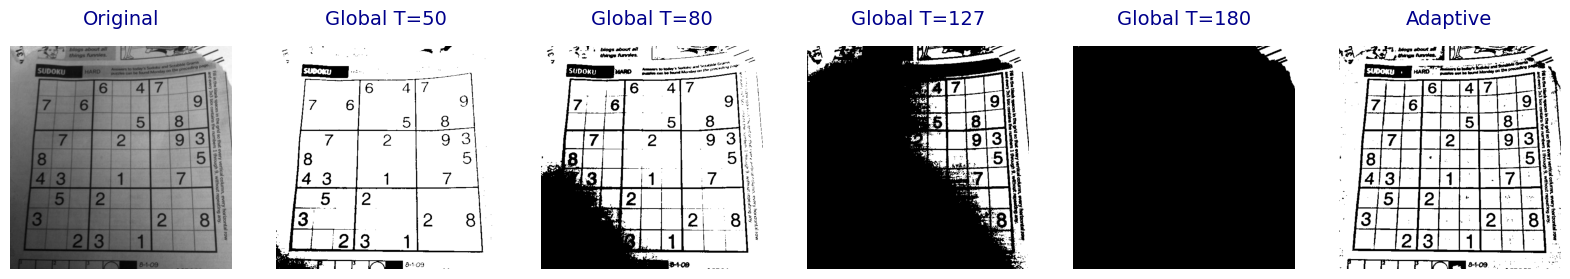

In [17]:
panels = [('Original', image)]
panels += [(f'Global T={t}', m) for t, m in zip(thresholds, global_masks)]
panels += [('Adaptive', adaptive)]

fig, axes = plt.subplots(1, 6, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [19]:
N, M = image.shape
for title, m in panels[1:]:
    print(title, '- black pixels left:', round(np.mean(m[:, :M // 2] == 0), 3), 'right:', round(np.mean(m[:, M // 2:] == 0), 3))

Global T=50 - black pixels left: 0.111 right: 0.055
Global T=80 - black pixels left: 0.408 right: 0.108
Global T=127 - black pixels left: 0.968 right: 0.526
Global T=180 - black pixels left: 1.0 right: 0.976
Adaptive - black pixels left: 0.185 right: 0.204


# Task 2

In [22]:
block_size = [3, 11, 51]
c_values = [0, 5, 15]

methods = {"Mean":cv2.ADAPTIVE_THRESH_MEAN_C, "Gaussian":cv2.ADAPTIVE_THRESH_GAUSSIAN_C}
results = {}

for name, method in methods.items():
  for b in block_size:
    for c in c_values:
      results[(name, b, c)] = cv2.adaptiveThreshold(image, 255, method, cv2.THRESH_BINARY, b, c)

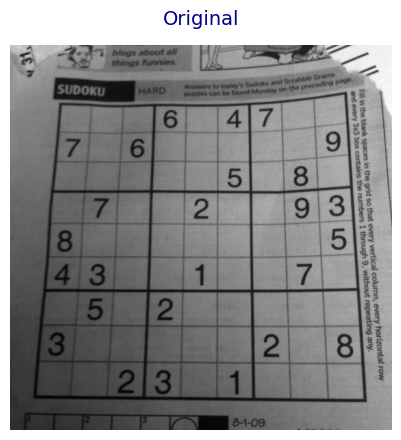

In [24]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(image, cmap='gray')
plt.title('Original', fontsize=14, color='darkblue', pad=15)
plt.show()

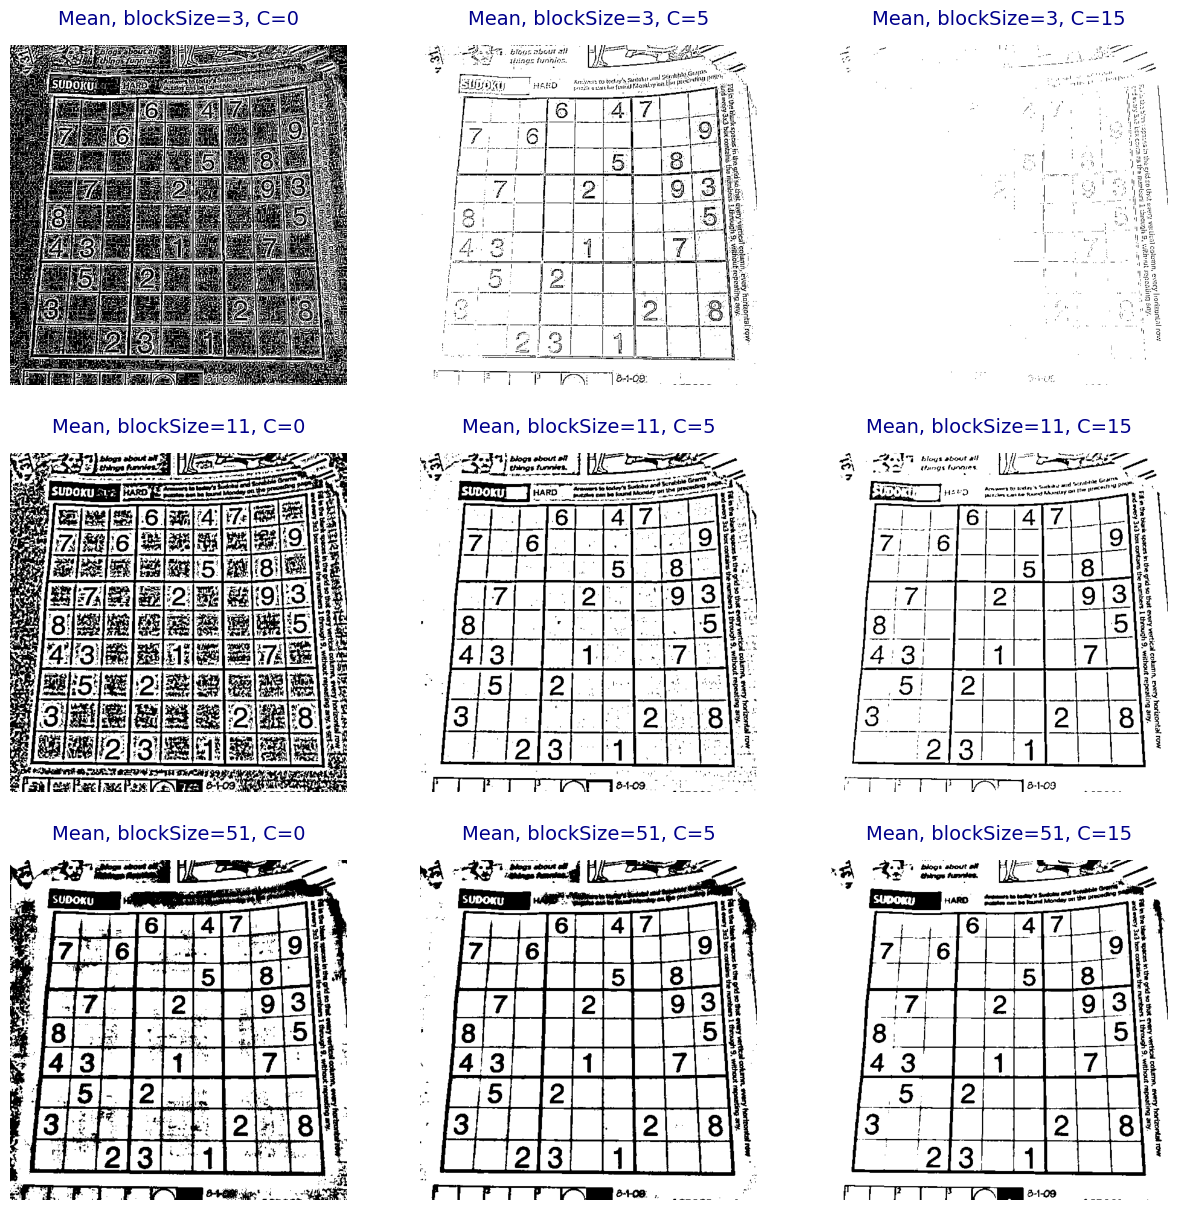

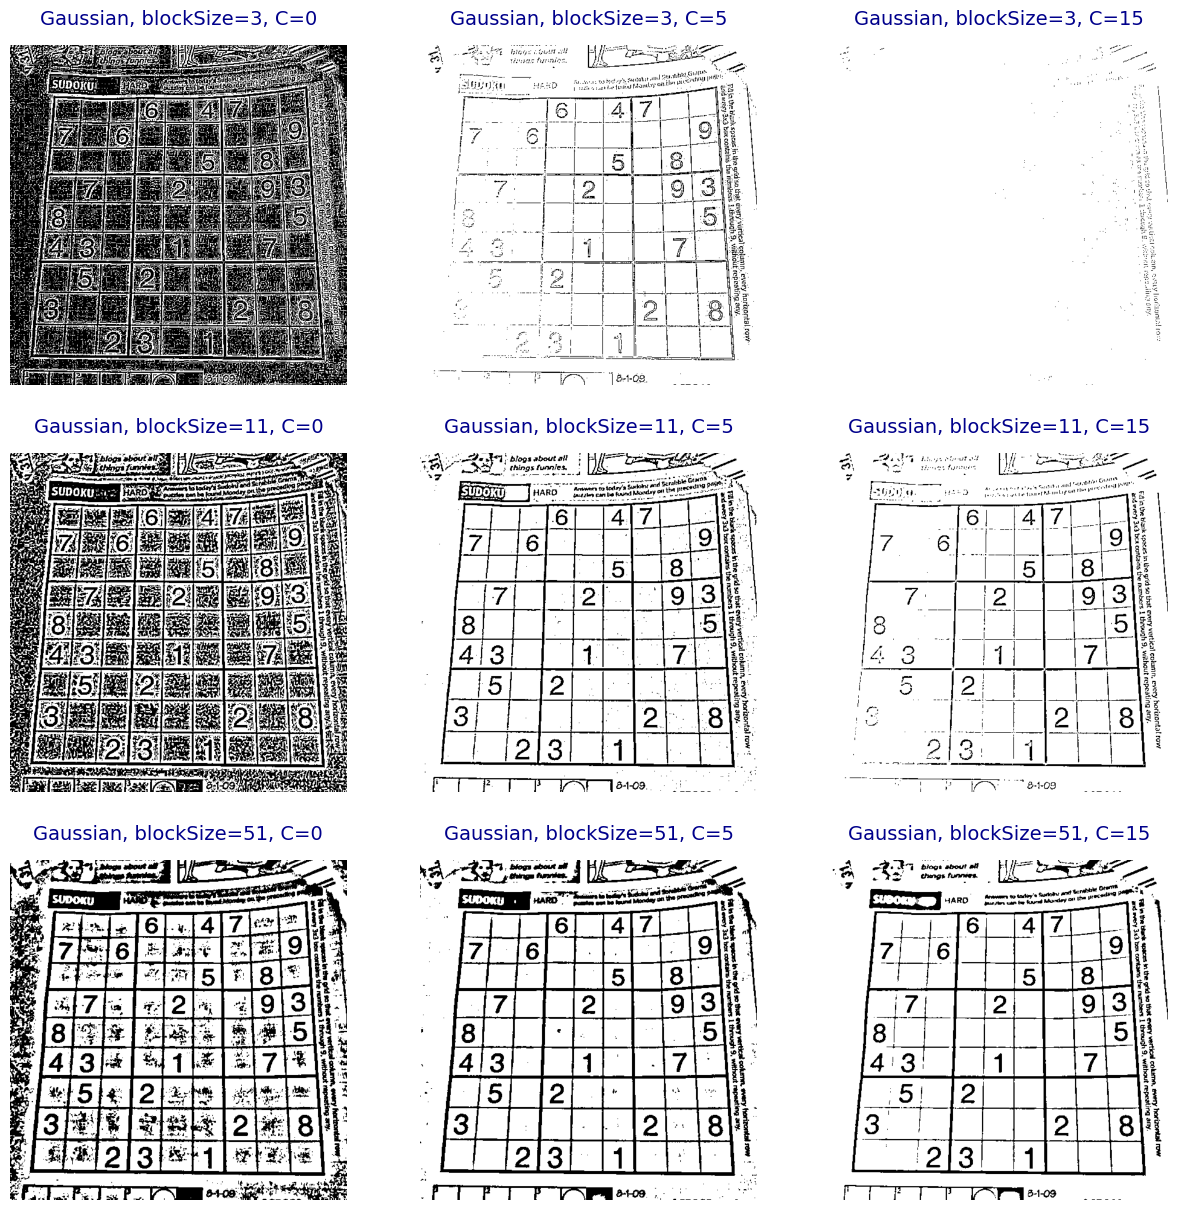

In [25]:
for name in methods:
    panels = [(f'{name}, blockSize={b}, C={c}', results[(name, b, c)]) for b in block_size for c in c_values]
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    for ax, (title, im) in zip(axes, panels):
        ax.imshow(im, cmap='gray')
        ax.axis('off')
        ax.set_title(title, fontsize=14, color='darkblue', pad=15)

    plt.show()

In [28]:
for key, m in results.items():
    print(key, '- black pixels:', round(np.mean(m == 0), 3))

('Mean', 3, 0) - black pixels: 0.63
('Mean', 3, 5) - black pixels: 0.087
('Mean', 3, 15) - black pixels: 0.011
('Mean', 11, 0) - black pixels: 0.446
('Mean', 11, 5) - black pixels: 0.174
('Mean', 11, 15) - black pixels: 0.119
('Mean', 51, 0) - black pixels: 0.288
('Mean', 51, 5) - black pixels: 0.209
('Mean', 51, 15) - black pixels: 0.158
('Gaussian', 3, 0) - black pixels: 0.665
('Gaussian', 3, 5) - black pixels: 0.067
('Gaussian', 3, 15) - black pixels: 0.004
('Gaussian', 11, 0) - black pixels: 0.493
('Gaussian', 11, 5) - black pixels: 0.144
('Gaussian', 11, 15) - black pixels: 0.08
('Gaussian', 51, 0) - black pixels: 0.32
('Gaussian', 51, 5) - black pixels: 0.194
('Gaussian', 51, 15) - black pixels: 0.143


# Task 3 - otsu thresholding

In [29]:
image = cv2.imread("water_coins.jpg", cv2.IMREAD_GRAYSCALE)
image.shape

(312, 252)

In [30]:
t_otsu, mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_otsu

162.0

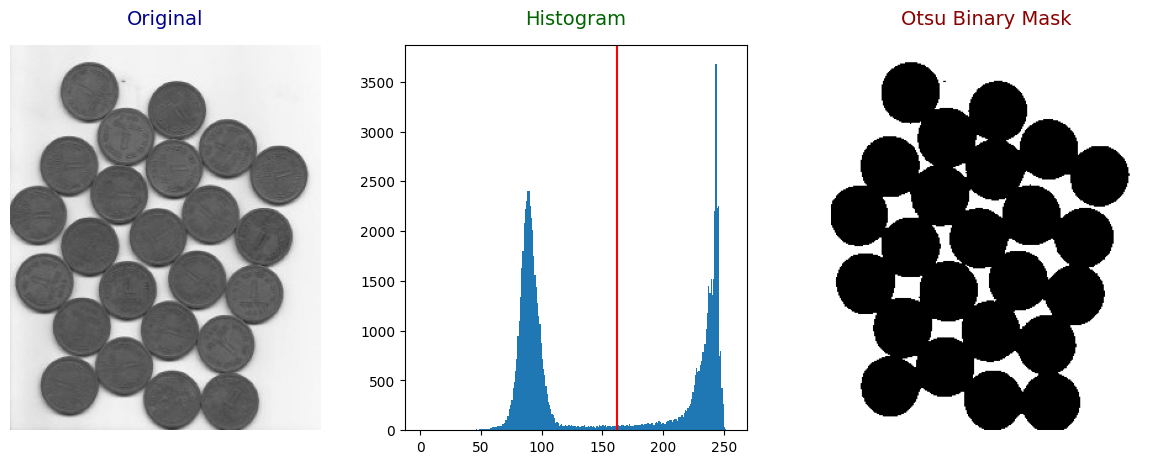

In [31]:
color_img = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(color_img)
axes[0].axis('off')
axes[0].set_title("Original", fontsize=14, color='darkblue', pad=15)

axes[1].hist(image.ravel(), bins=256, range=(0, 256))
axes[1].axvline(t_otsu, color='red')
axes[1].set_title("Histogram", fontsize=14, color='darkgreen', pad=15)

axes[2].imshow(mask, cmap='gray')
axes[2].axis('off')
axes[2].set_title("Otsu Binary Mask", fontsize=14, color='darkred', pad=15)

plt.show()

Original - threshold: 162.0
Blurred - threshold: 162.0
Higher contrast - threshold: 194.0
Brighter - threshold: 196.0


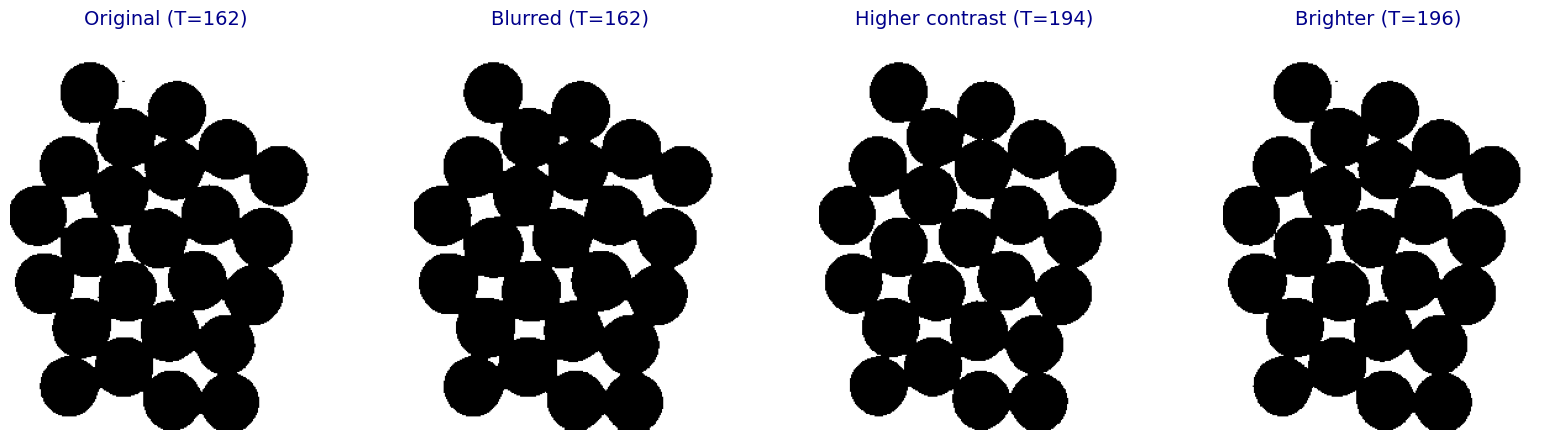

In [32]:
variants = {
    'Original': image,
    'Blurred': cv2.GaussianBlur(image, (5, 5), 0),
    'Higher contrast': cv2.convertScaleAbs(image, alpha=1.5, beta=0),
    'Brighter': cv2.convertScaleAbs(image, alpha=1, beta=50),
}

panels = []
for name, im in variants.items():
    t, m = cv2.threshold(im, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print(name, '- threshold:', t)
    panels.append((f'{name} (T={t:.0f})', m))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 4 - color based segmentation

In [7]:
image = cv2.imread("smarties.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image.shape

(356, 413, 3)

In [8]:
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

restrictive_lower, restrictive_upper = np.array([66, 240, 250]), np.array([68, 255, 255])
final_lower, final_upper = np.array([40, 80, 50]), np.array([85, 255, 255])

restrictive_mask = cv2.inRange(hsv, restrictive_lower, restrictive_upper)
final_mask = cv2.inRange(hsv, final_lower, final_upper)
extracted = cv2.bitwise_and(image, image, mask=final_mask)

print('restrictive mask pixels:', cv2.countNonZero(restrictive_mask))
print('final mask pixels:', cv2.countNonZero(final_mask))

restrictive mask pixels: 2106
final mask pixels: 5362


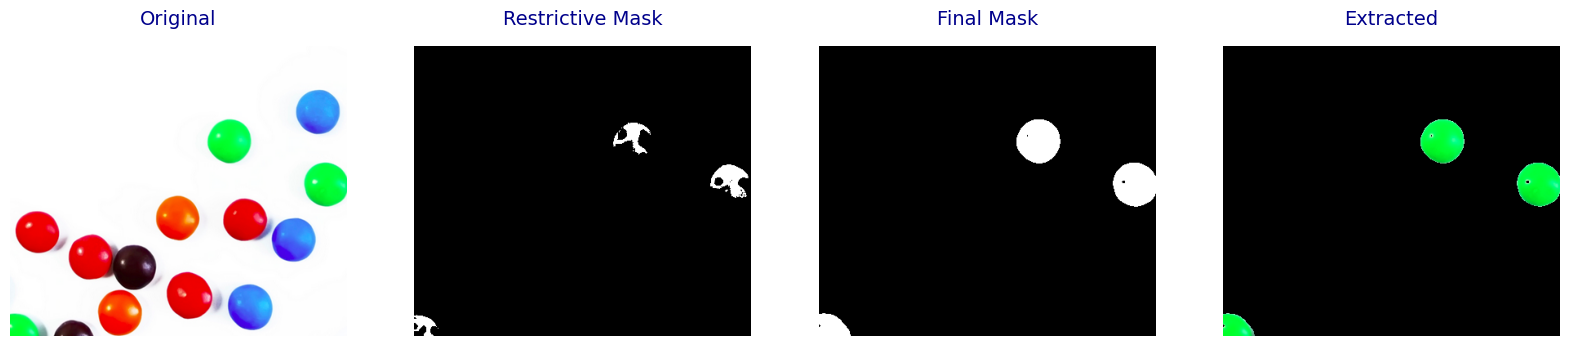

In [10]:
panels = [('Original', image), ('Restrictive Mask', restrictive_mask), ('Final Mask', final_mask), ('Extracted', extracted)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 5 - Canny edge detection

In [11]:
image = cv2.imread("smarties.png", cv2.IMREAD_GRAYSCALE)
image.shape

(356, 413)

In [12]:
blurred = cv2.GaussianBlur(image, (5,5), 0)

pairs = [(50, 100), (50, 200), (150, 250)]
edges = [cv2.Canny(blurred, low, high) for low, high in pairs]

for (low, high), e in zip(pairs, edges):
    print(f'low={low}, high={high} - edge pixels:', cv2.countNonZero(e))

low=50, high=100 - edge pixels: 3272
low=50, high=200 - edge pixels: 2993
low=150, high=250 - edge pixels: 2813


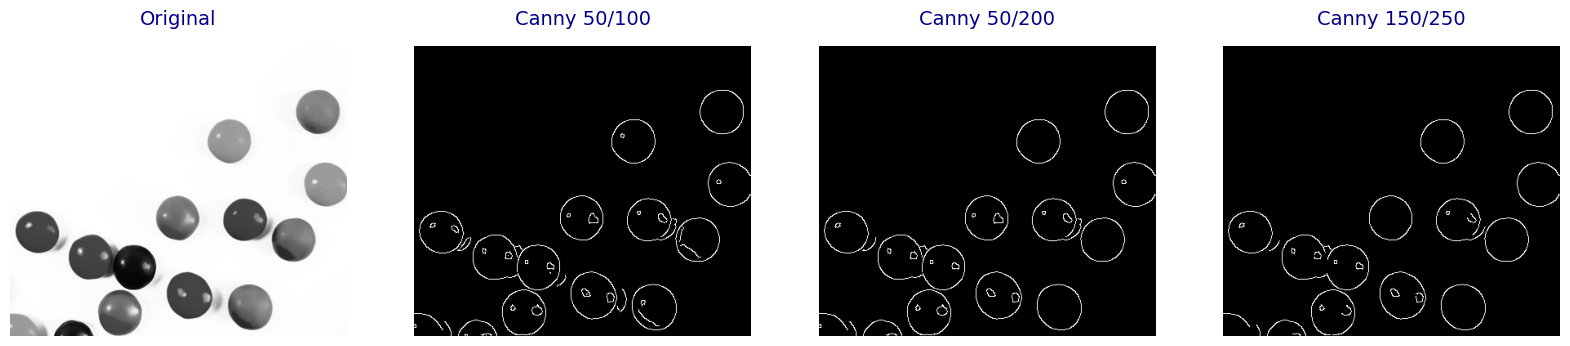

In [13]:
panels = [('Original', image)]
panels += [(f'Canny {low}/{high}', e) for (low, high), e in zip(pairs, edges)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 6 - region growing

In [14]:
image = cv2.imread("mri.png", cv2.IMREAD_GRAYSCALE)
image.shape

(388, 371)

In [15]:
from itertools import product
from collections import deque

def region_growing(image, seed, threshold):
  N, M = image.shape
  seed_value = int(image[seed])
  mask = np.zeros((N, M), dtype=np.uint8)
  mask[seed] = 255
  queue = deque([seed])
  while queue:
    y, x = queue.popleft()
    for dy, dx in product((-1, 0, 1), (-1, 0, 1)):
      ny, nx = y+dy, x+dx
      if 0 <= ny < N and 0 <= nx < M and abs(int(image[ny, nx]) - seed_value) <= threshold and mask[ny, nx] == 0:
        mask[ny, nx] = 255
        queue.append((ny, nx))
  return mask

seed=(130, 90), threshold=5 - region size: 30242
seed=(130, 90), threshold=15 - region size: 34871
seed=(130, 90), threshold=30 - region size: 45005
seed=(110, 185), threshold=5 - region size: 33
seed=(110, 185), threshold=15 - region size: 6297
seed=(110, 185), threshold=30 - region size: 19307


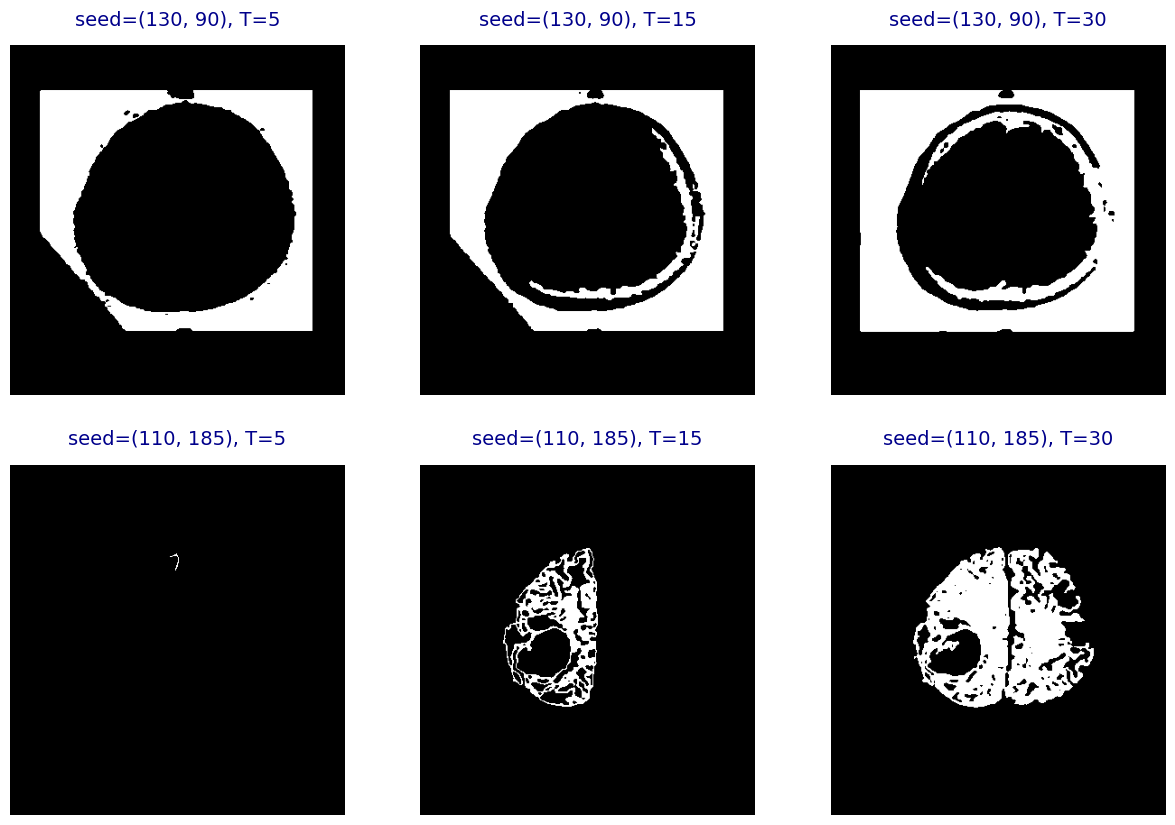

In [19]:
blurred = cv2.GaussianBlur(image, (5, 5), 0)

N, M = image.shape
seeds = [(130, 90), (110, 185)]
thresholds = [5, 15, 30]

panels = []
for seed in seeds:
    for t in thresholds:
        mask = region_growing(blurred, seed, t)
        print(f'seed={seed}, threshold={t} - region size:', cv2.countNonZero(mask))
        panels.append((f'seed={seed}, T={t}', mask))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

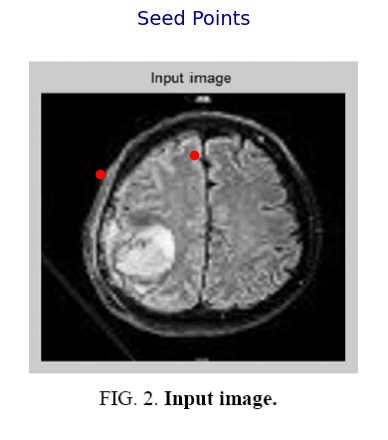

In [21]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(image, cmap='gray')
for y, x in seeds:
    plt.plot(x, y, 'r.', markersize=12)
plt.title('Seed Points', fontsize=14, color='darkblue', pad=15)
plt.show()

# Task 7 - watershed

In [25]:
image_path = 'water_coins.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(312, 252, 3)

In [27]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5,5), 0)
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel, iterations = 2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

In [28]:
_, sure_fg = cv2.threshold(dist, 0.5*dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

num_labels, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

result = img.copy()
markers = cv2.watershed(result, markers)
result[markers == -1] = (255, 0, 0)

In [29]:
print('foreground markers:', num_labels - 1)
print('separated regions:', len(np.unique(markers)) - 2)

foreground markers: 24
separated regions: 24


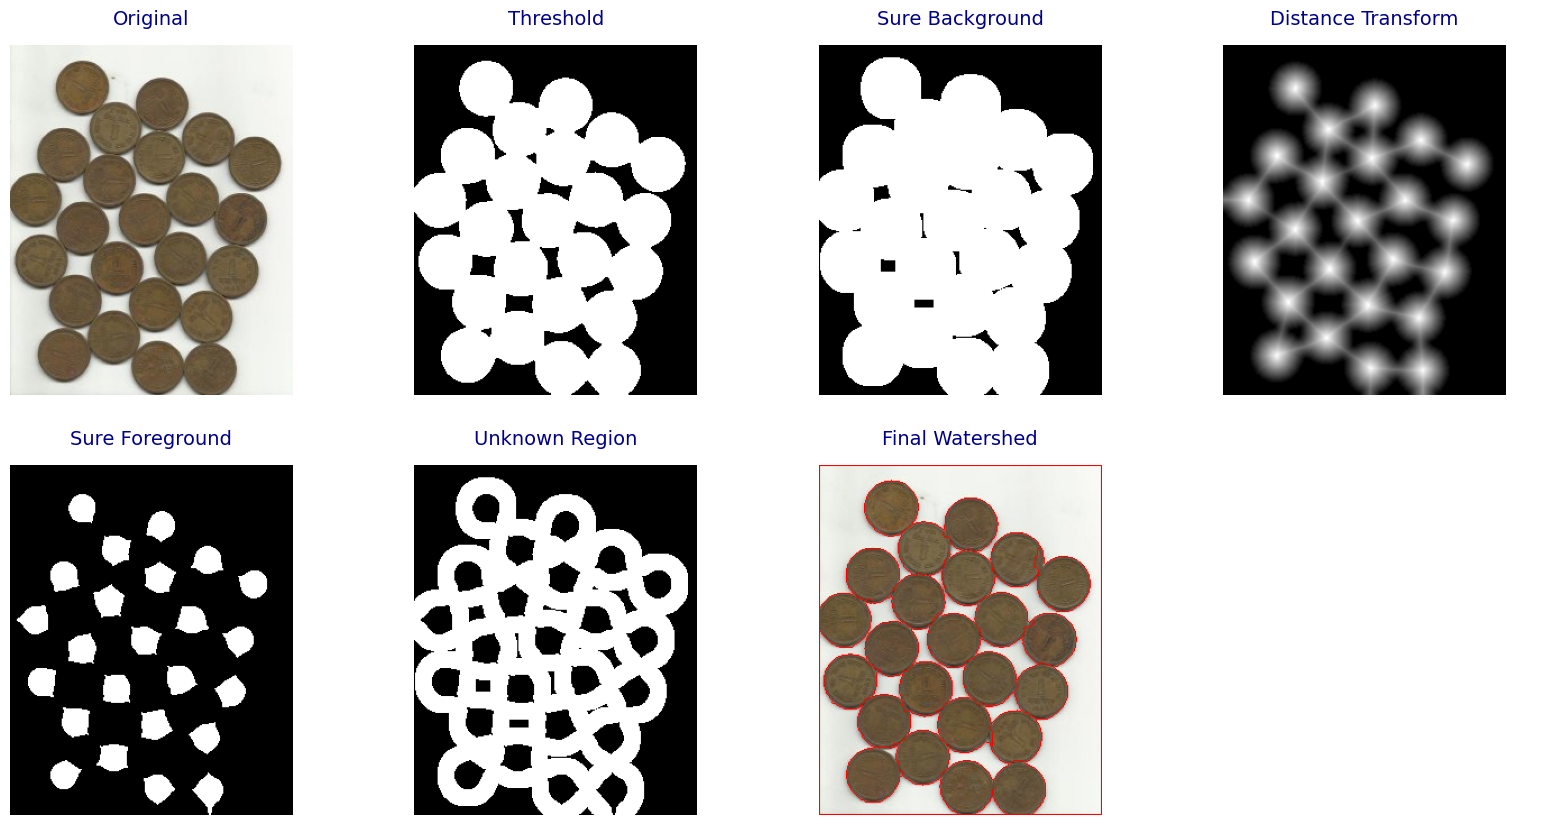

In [30]:
panels = [
    ('Original', img),
    ('Threshold', thresh),
    ('Sure Background', sure_bg),
    ('Distance Transform', dist),
    ('Sure Foreground', sure_fg),
    ('Unknown Region', unknown),
    ('Final Watershed', result),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

axes[-1].axis('off')
plt.show()

# Task 8

In [31]:
import pandas as pd
image_path = 'water_coins.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(312, 252, 3)

In [32]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

In [33]:
ratios = [0.2, 0.4, 0.5, 0.7, 0.95]
rows = []
panels = []

for ratio in ratios:
    _, sure_fg = cv2.threshold(dist, ratio * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    num_labels, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    result = img.copy()
    markers = cv2.watershed(result, markers)
    result[markers == -1] = (255, 0, 0)

    rows.append({'Distance Threshold': ratio, 'Foreground Markers': num_labels - 1, 'Regions': len(np.unique(markers)) - 2})
    panels.append((f'Threshold = {ratio} * max', result))

pd.DataFrame(rows)

,Distance Threshold,Foreground Markers,Regions
0,0.20,1,1
1,0.40,7,7
2,0.50,24,24
3,0.70,24,24
4,0.95,24,24


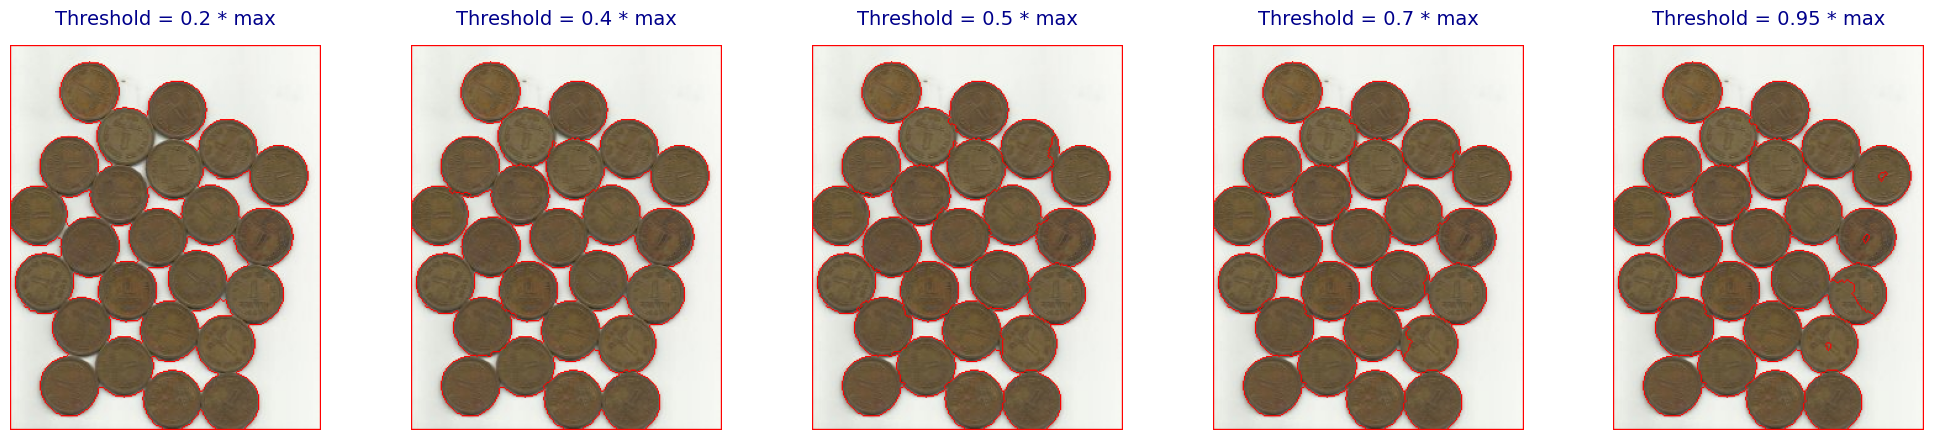

In [34]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 9 - kmeans image segmentation

In [35]:
image_path = 'dog.jpeg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(350, 233, 3)

In [36]:
pixels = img.reshape(-1, 3)
pixels = np.float32(pixels)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)

panels = [('Original', img)]
for k in [2, 4, 6]:
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented = centers[labels.flatten()].reshape(img.shape)
    panels.append((f'K={k}', segmented))
    print(f'K={k} cluster centers (RGB):')
    print(centers)

K=2 cluster centers (RGB):
[[180 147 142]
 [ 90  66  59]]
K=4 cluster centers (RGB):
[[166 124 115]
 [ 75  56  53]
 [200 181 182]
 [116  84  70]]
K=6 cluster centers (RGB):
[[198 133 120]
 [161 147 156]
 [209 193 192]
 [141 105  89]
 [ 73  55  53]
 [106  76  64]]


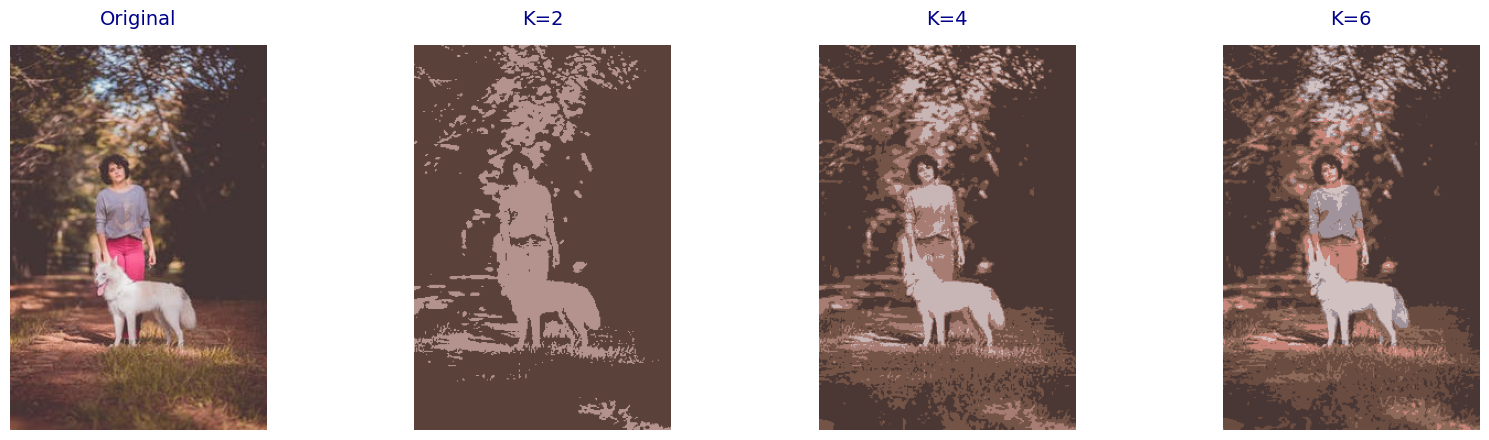

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, )
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 10

In [38]:
image_path = 'dog.jpeg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(350, 233, 3)

In [39]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

_, otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

pixels = np.float32(img.reshape(-1, 3))
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, labels, centers = cv2.kmeans(pixels, 4, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
kmeans = np.uint8(centers)[labels.flatten()].reshape(img.shape)

canny = cv2.Canny(blurred, 50, 150)

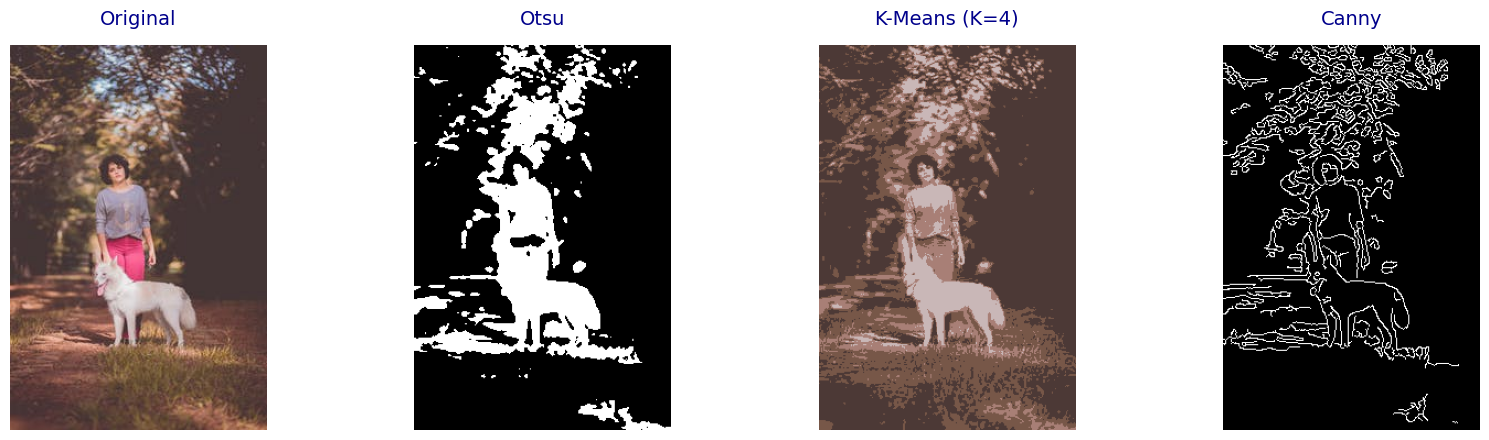

In [40]:
panels = [('Original', img), ('Otsu', otsu), ('K-Means (K=4)', kmeans), ('Canny', canny)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()